# Análise Exploratória

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:\\Users\\User\\Desktop\\Data Science\\Machine Learning Finanças Detecção de Fraudes\\fraud_dataset_example.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

Trazendo as colunas de Fraude para o começo do dataset

In [4]:
df = df [['isFraud','isFlaggedFraud','step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 
'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest']]
df.head()

,isFraud,isFlaggedFraud,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest
0,0,0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0
1,0,0,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0
2,1,0,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0
3,1,0,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0
4,0,0,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0


Renomeando as Colunas

In [5]:
colunas = {
    'isFraud': 'fraude',
    'isFlaggedFraud':'super_fraude',
    'step':'tempo',
    'type':'tipo',
    'amount':'valor',
    'nameOrig':'cliente1',
    'oldbalanceOrg':'saldo_inicial_c1',
    'newbalanceOrig':'novo_saldo_c1',
    'nameDest':'cliente2',
    'oldbalanceDest':'saldo_inicial_c2',
    'newbalanceDest':'novo_saldo_c2',
}

In [6]:
df = df.rename(columns= colunas)
df.head()

,fraude,super_fraude,tempo,tipo,valor,cliente1,saldo_inicial_c1,novo_saldo_c1,cliente2,saldo_inicial_c2,novo_saldo_c2
0,0,0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0
1,0,0,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0
2,1,0,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0
3,1,0,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0
4,0,0,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0


Outras Informações do dataset

In [7]:
df.describe()

,fraude,super_fraude,tempo,valor,saldo_inicial_c1,novo_saldo_c1,saldo_inicial_c2,novo_saldo_c2
count,101613.000000,101613.0,101613.000000,1.016130e+05,1.016130e+05,1.016130e+05,1.016130e+05,1.016130e+05
mean,0.001142,0.0,8.523457,1.740901e+05,9.071753e+05,9.234992e+05,8.810428e+05,1.183998e+06
std,0.033768,0.0,1.820681,3.450199e+05,2.829575e+06,2.867319e+06,2.399949e+06,2.797761e+06
min,0.000000,0.0,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000,0.0,8.000000,1.001659e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000,0.0,9.000000,5.338541e+04,2.019047e+04,0.000000e+00,2.105800e+04,5.178343e+04
75%,0.000000,0.0,10.000000,2.124984e+05,1.947150e+05,2.192178e+05,5.919217e+05,1.063122e+06
max,1.000000,0.0,10.000000,1.000000e+07,3.893942e+07,3.894623e+07,3.400874e+07,3.894623e+07


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fraude,101613.0,1.141586e-03,3.376824e-02,0.00,0.00,0.00,0.00,1.00
super_fraude,101613.0,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00,0.00
tempo,101613.0,8.523457e+00,1.820681e+00,1.00,8.00,9.00,10.00,10.00
valor,101613.0,1.740901e+05,3.450199e+05,0.32,10016.59,53385.41,212498.40,10000000.00
saldo_inicial_c1,101613.0,9.071753e+05,2.829575e+06,0.00,0.00,20190.47,194715.00,38939424.03
novo_saldo_c1,101613.0,9.234992e+05,2.867319e+06,0.00,0.00,0.00,219217.76,38946233.02
saldo_inicial_c2,101613.0,8.810428e+05,2.399949e+06,0.00,0.00,21058.00,591921.70,34008736.98
novo_saldo_c2,101613.0,1.183998e+06,2.797761e+06,0.00,0.00,51783.43,1063121.64,38946233.02


In [9]:
# Quantidade de linha e colunas
df.shape 

(101613, 11)

(101613, 11)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101613 entries, 0 to 101612
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   fraude            101613 non-null  int64  
 1   super_fraude      101613 non-null  int64  
 2   tempo             101613 non-null  int64  
 3   tipo              101613 non-null  object 
 4   valor             101613 non-null  float64
 5   cliente1          101613 non-null  object 
 6   saldo_inicial_c1  101613 non-null  float64
 7   novo_saldo_c1     101613 non-null  float64
 8   cliente2          101613 non-null  object 
 9   saldo_inicial_c2  101613 non-null  float64
 10  novo_saldo_c2     101613 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 8.5+ MB


Verificando a variável de target (Fraude)

In [11]:
# 0 = sem fraude - Não ocorreu fraude em 101497 transações
# 1 = Fraude - ocorreu fraude 116 transações
# A Segunda coluna é a contagem
df.groupby('fraude').tempo.count()

fraude
0    101497
1       116
Name: tempo, dtype: int64

In [12]:
# Não existem valores nulos para serem tratados
df.isnull().values.any()

np.False_

Enconding

In [13]:
# pip install ydata-profiling
# pip install ipywidgets
from ydata_profiling import ProfileReport

In [14]:
# SUMARIZAÇÃO DO DATASET
ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:02<00:00,  4.30it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Aplicando o Encoding

Transformando a variável TIPO de categórica para True/False

In [15]:
df = pd.get_dummies(data=df, columns=['tipo'])
df.head()

,fraude,super_fraude,tempo,valor,cliente1,saldo_inicial_c1,novo_saldo_c1,cliente2,saldo_inicial_c2,novo_saldo_c2,tipo_CASH_IN,tipo_CASH_OUT,tipo_DEBIT,tipo_PAYMENT,tipo_TRANSFER
0,0,0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,False,False,False,True,False
1,0,0,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,False,False,False,True,False
2,1,0,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,False,False,False,False,True
3,1,0,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,False,True,False,False,False
4,0,0,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,False,False,False,True,False


Removendo Variáveis / Colunas

In [16]:
df = df.drop(['cliente1', 'cliente2', 'super_fraude'], axis = 1)

In [17]:
df.head()

,fraude,tempo,valor,saldo_inicial_c1,novo_saldo_c1,saldo_inicial_c2,novo_saldo_c2,tipo_CASH_IN,tipo_CASH_OUT,tipo_DEBIT,tipo_PAYMENT,tipo_TRANSFER
0,0,1,9839.64,170136.0,160296.36,0.0,0.0,False,False,False,True,False
1,0,1,1864.28,21249.0,19384.72,0.0,0.0,False,False,False,True,False
2,1,1,181.00,181.0,0.00,0.0,0.0,False,False,False,False,True
3,1,1,181.00,181.0,0.00,21182.0,0.0,False,True,False,False,False
4,0,1,11668.14,41554.0,29885.86,0.0,0.0,False,False,False,True,False


# Regressão Logística

In [18]:
x = df.drop('fraude', axis=1)
y = df['fraude']

In [19]:
from sklearn.model_selection import train_test_split
SEED = 42
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state =SEED)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

lr = LogisticRegression(max_iter=1000, random_state=SEED)

lr.fit(x_train, y_train) # Treinando o Modelo
y_pred =lr.predict(x_test) # Previsão

# Avaliando o Modelo
print("Acurácia:",metrics.accuracy_score(y_test, y_pred))
print("Precisão:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred)) 
print("F1:",metrics.f1_score(y_test, y_pred))

Acurácia: 0.9990552668871044
Precisão: 0.3333333333333333
Recall: 0.043478260869565216
F1: 0.07692307692307693


* A acurácia ficou bem alta: 0.99. Significa que o modelo, está acertando bastante. Porém, as outras métricas estão um pouco baixas.
* A precisão, que é a métrica que avalia a quantidade de verdadeiros positivos, ou seja, quantas vezes a fraude está acertando, está um pouco baixa: 0.2. 
Então, será avaliado melhor o que está acontecendo.
* O Recall diz respeito à nossa sensibilidade, à reevocação. Ele avalia a capacidade do modelo classificar corretamente as classes, sejam elas fraudes ou não, 0 ou 1. Se temos um valor de 0.4, quer dizer que não estamos acertando tão bem.
* O f1_score, que é a média harmônica entre a nossa precisão e o nosso recall. Um ponto interessante é que quando temos uma acurácia muito alta e um F1 muito baixo, é sinal de que, talvez, a nossa acurácia não seja tão confiável. 

# Plot da Matriz de confusão

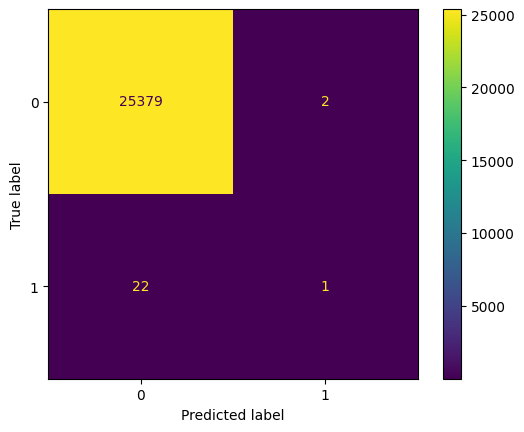

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.datasets import make_classification
from sklearn.metrics import ConfusionMatrixDisplay
%matplotlib inline
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Do lado esquerdo, os valores marcados com zero seriam os nossos verdadeiros negativos, são as partes que não são fraudes e estão acertando muito, porém, o verdadeiro positivo acertou apenas uma vez. Algo diferente, portanto, está acontecendo: ele está acertando muito em uma classe e pouco em outra. Os outros valores estão bem baixos.

Apesar de não sabermos exatamente o que está acontecendo, podemos arriscar um palpite. Nós estudamos anteriormente que as classes estão um pouco desbalanceadas, a classe majoritária era a classe de mais valores que não são fraude, mas também podemos avaliar o nosso modelo com outra métrica que a Curva Roc.

Com a Curva Roc conseguimos validar o modelo em si. Ela é característica de operação do receptor e se trata de uma curva que se aproxima do valor 1. Nós vamos avaliá-la considerando quão próxima está do valor 1. Além disso, ela trará outra métrica junto que é a AUC (Are Under the Curve) ou Área sob a curva.

# Plot Curva ROC

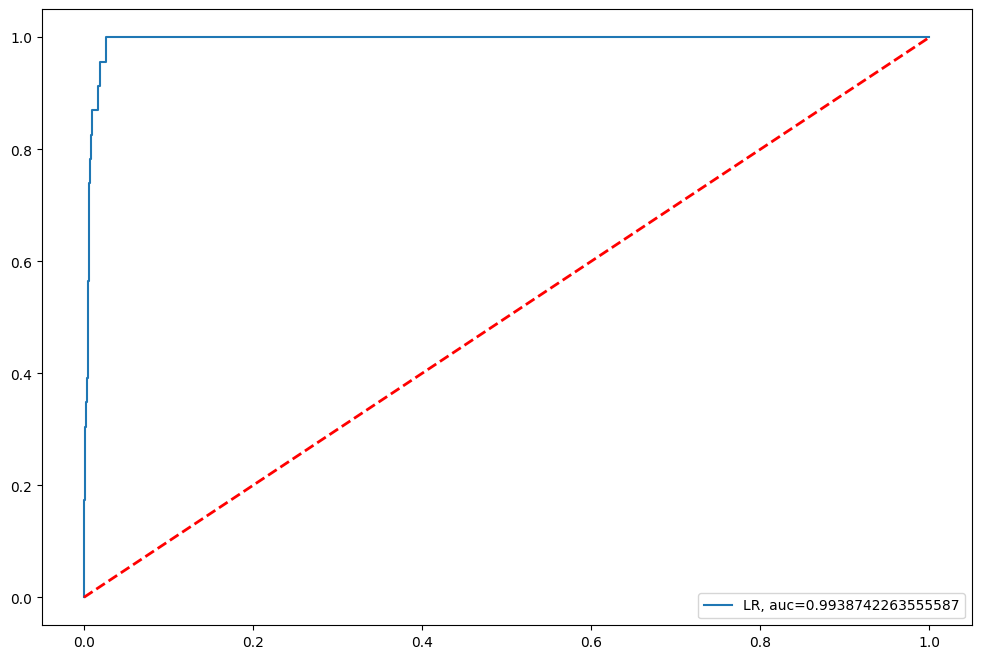

In [22]:
y_pred_proba = lr.predict_proba(x_test)[::, 1]
fpr, tpr, _= metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

plt.rcParams['figure.figsize'] = (12., 8.)
plt.plot(fpr,tpr,label="LR, auc="+str(auc))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.legend(loc=4)


Na Curva Roc, quanto mais perto de 1 fica a curva azul fica, melhor ela é. Quanto mais rápido ela chega no valor 1 do eixo y, melhor. É possível notar que a subida da curva azul está um pouco estranha, quadrada. Até (0.2, 1.0) ela ainda está tentando se estabilizar, a partir desse ponto ela se estabiliza e chega até o ponto de estabilização que é o 1, ao final.

Mas, ela está com uma curva de AUC boa, com valor de 0.958. A acurácia está boa, mas as nossas outras métricas, não. Provavelmente isso está acontecendo, porque as classes estão desbalanceadas, o que atrapalha os nossos modelos e o trabalho com as classes. É necessário corrigir esse problema para que esse e os modelos futuros tenham um desempenho melhor quanto às nossas métricas.

# Balanceamento de Dados - KNN:

Nossa base de dados está desbalanceada: temos apenas **116 casos de fraude**, o que impactou negativamente o desempenho do modelo de machine learning.

Para resolver isso, existem duas técnicas principais:

*1. **Undersampling** – reduz a quantidade de dados da classe majoritária (não fraude) para equilibrar com a minoritária (fraude). Porém, isso descartaria muitos dados úteis e comprometeria a análise, já que temos poucos dados de fraude.

*2. **Oversampling** – aumenta artificialmente os dados da classe minoritária, replicando ou criando novos exemplos de fraude até equilibrar com os de não fraude. Isso pode causar problemas se estivermos lidando com dados reais, mas como usamos uma base sintética, é uma opção viável.

Uma técnica de oversampling mais sofisticada é o **SMOTE**, que usa o algoritmo **KNN (K-Nearest Neighbors)** para criar novos exemplos de fraude com base na proximidade entre os existentes, gerando dados mais variados e realistas, em vez de apenas duplicar registros. Essa abordagem é adequada para nosso caso.


In [23]:
#pip install -U imbalanced-learn
from imblearn.over_sampling import SMOTE
import numpy as np

SEED=42

smote = SMOTE(random_state=42)

In [24]:
x = df.drop('fraude', axis=1)
y = df['fraude']

In [25]:
x_resampled, y_resampled = smote.fit_resample(x,y)

In [26]:
df_balanced = pd.concat([y_resampled, x_resampled], axis=1)
df_balanced

,fraude,tempo,valor,saldo_inicial_c1,novo_saldo_c1,saldo_inicial_c2,novo_saldo_c2,tipo_CASH_IN,tipo_CASH_OUT,tipo_DEBIT,tipo_PAYMENT,tipo_TRANSFER
0,0,1,9839.640000,170136.000000,160296.36,0.000000,0.000000,False,False,False,True,False
1,0,1,1864.280000,21249.000000,19384.72,0.000000,0.000000,False,False,False,True,False
2,1,1,181.000000,181.000000,0.00,0.000000,0.000000,False,False,False,False,True
3,1,1,181.000000,181.000000,0.00,21182.000000,0.000000,False,True,False,False,False
4,0,1,11668.140000,41554.000000,29885.86,0.000000,0.000000,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
202989,1,5,17608.962863,17608.962863,0.00,0.000000,0.000000,False,False,False,False,True
202990,1,7,12116.291013,12116.291013,0.00,0.000000,0.000000,False,False,False,False,True
202991,1,1,231612.880715,231612.880715,0.00,1945.589357,9370.603471,False,True,False,False,True
202992,1,9,547325.144758,547325.144758,0.00,0.000000,0.000000,False,False,False,False,True


In [27]:
df_balanced.groupby('fraude').tempo.count()

fraude
0    101497
1    101497
Name: tempo, dtype: int64

In [28]:
x = df_balanced.iloc[:, 1:].values
y = df_balanced.iloc[:, 0].values

In [29]:
from sklearn.model_selection import train_test_split

SEED = 42

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state = SEED)

from sklearn.linear_model import LogisticRegression
from sklearn import metrics

lr = LogisticRegression(max_iter=1000, random_state=SEED)

lr.fit(x_train, y_train)
y_pred =lr.predict(x_test)

print("Acurácia:",metrics.accuracy_score(y_test, y_pred))
print("Precisão:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred)) 
print("F1:",metrics.f1_score(y_test, y_pred))

Acurácia: 0.965437742615618
Precisão: 0.96745679403837
Recall: 0.9631807419100237
F1: 0.9653140325897801


Apesar da acurácia ter caído para 0,94, as outras métricas melhoraram significativamente:

* Precisão: 0,92
* Recall (sensibilidade): 0,96
* F1-Score: 0,94

Esses resultados indicam que o modelo está mais equilibrado e eficaz na detecção de fraudes, especialmente porque o F1-Score — que considera tanto precisão quanto recall — está alto. Isso mostra uma melhora real no desempenho, diferente das versões anteriores.

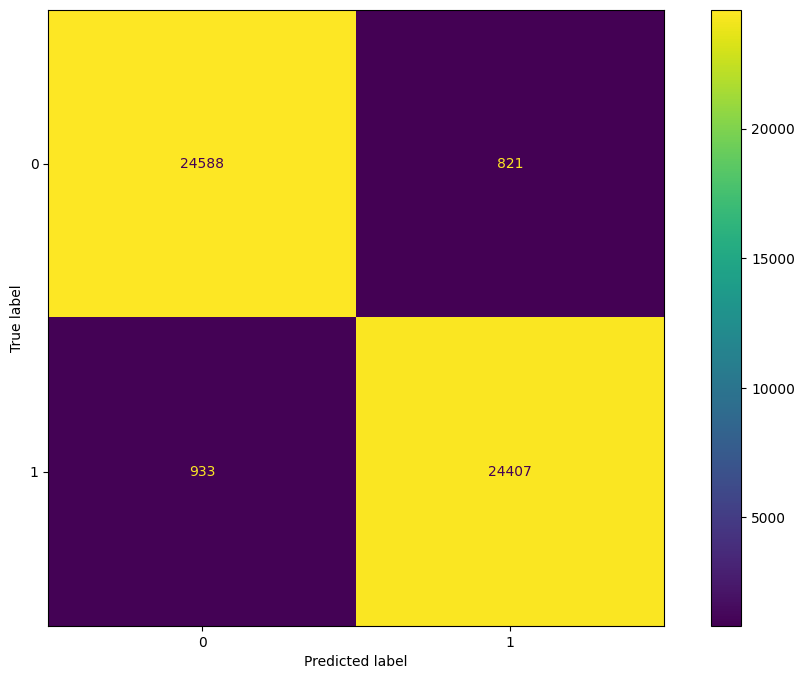

In [30]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

A matriz de confusão melhorou bastante: 
* O modelo está mais balanceado e acertou mais casos de fraude do que de não-fraude, o que é visível pela intensidade maior na área correspondente. 
* **Isso mostra que o modelo está mais eficiente na detecção de fraudes.**

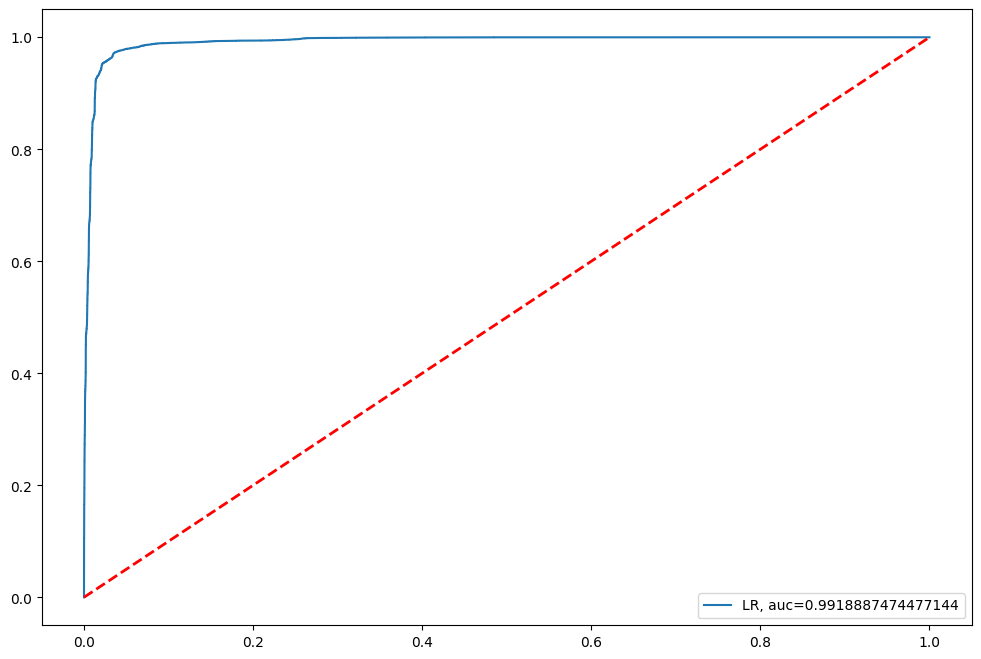

In [31]:
y_pred_proba = lr.predict_proba(x_test)[::, 1]
fpr, tpr, _= metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

plt.rcParams['figure.figsize'] = (12., 8.)
plt.plot(fpr,tpr,label="LR, auc="+str(auc))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.legend(loc=4)

A **Curva ROC** melhorou significativamente. Antes, apresentava muito **zigue-zague** entre os valores **0.0 e 0.2** no eixo X, o que comprometia sua performance. 

Agora, a nova curva tem **subida mais rápida**, **mais linearidade** e **menos oscilações**, indicando um modelo mais estável.

Além disso, a **AUC (Área sob a Curva)** aumentou de **0,958 para 0,963**, mostrando um desempenho geral melhor do classificador.

**Conclusão:** 

O **balanceamento de dados** teve impacto positivo e melhorou significativamente a **regressão logística**, tornando o modelo mais eficiente na detecção de fraudes.


# Formulando Hipóteses

In [32]:
ProfileReport(df_balanced)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 14.50it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Após os testes e o balanceamento dos dados, foi feita uma nova análise exploratória usando o Pandas Profiling com o df_balanced. O objetivo foi identificar variáveis correlacionadas com fraudes e formular hipóteses para explicar sua ocorrência.

**Principais achados:**

A análise gerou **vários alertas**, indicando variáveis com alta correlação com a variável fraude.

**Variáveis mais correlacionadas com fraudes:**

* tempo (altamente correlacionado)

* tipo_CASH_IN

* tipo_PAYMENT

* tipo_TRANSFER

* novo_saldo_c1
  


**Matriz Correlação**
A matriz de correlação é como um mapa que mostra se duas coisas estão ligadas de alguma forma. No nosso caso, estamos vendo se **determinadas ações ou comportamentos estão ligados à ocorrência de fraudes.**

**Matriz Correlação mostra que:**

1. **"tipo_PAYMENT" tem correlação negativa com fraudes:**

Isso quer dizer que **quando o pagamento é feito do tipo "PAYMENT" (pagamento comum), é mais provável que não seja uma fraude. Ou seja, esse tipo de transação costuma ser legítima.

2. **"tipo_TRANSFER" tem correlação positiva com fraudes:**

Aqui, o contrário: quando o tipo de operação é "TRANSFER" (transferência de dinheiro), é mais comum que seja uma fraude. Isso indica que os golpistas costumam usar esse tipo de transação.

3. **O "tempo" tem forte relação com fraudes:**

Isso quer dizer que o momento do dia ou do mês em que a transação acontece pode indicar se é uma fraude ou não. Por exemplo, se um cliente costuma fazer pagamentos de manhã e de repente aparece uma transação à meia-noite, isso pode ser um sinal de fraude.

---


**Hipóteses levantadas:**

**1. Fraudes ocorrem principalmente em transações do tipo TRANSFER, enquanto transações legítimas são mais frequentes em PAYMENT.**

**2. Clientes costumam transacionar em horários específicos (ex: manhã), e fraudes ocorrem em horários atípicos (ex: madrugada).**

**3. Clientes fazem movimentações no início do mês, e fraudes tendem a ocorrer no final do mês, fora do padrão usual.**

# Árvore de Decisão:

Para comparar o desempenho do modelo de regressão logística, foi implementado um novo modelo de machine learning: **Árvore de Decisão**. Esse modelo funciona por meio de bifurcações (ramos) que levam a decisões finais (folhas). Para evitar **overfitting** — quando o modelo se ajusta demais aos dados de treino e perde desempenho com dados novos — foi limitada sua profundidade a 5 (usando `max_depth=5`).

O modelo foi treinado com os mesmos passos da regressão logística e avaliado com as mesmas métricas:

* **Acurácia:** 0.96
* **Precisão:** 0.93
* **Recall:** 0.98
* **F1-Score:** 0.96

Esses resultados são melhores que os obtidos com o modelo anterior. 

A matriz de confusão também mostrou redução significativa nos erros. 

Além disso, a **Curva ROC** apresentou uma **AUC de 0.988**, indicando excelente performance.

Conclui-se que a **Árvore de Decisão** superou o modelo de regressão logística nos principais indicadores, mostrando-se uma opção mais eficaz para este problema.


In [33]:
from sklearn.tree import DecisionTreeClassifier

In [34]:
dt =  DecisionTreeClassifier(max_depth = 5, random_state=SEED)

In [35]:
model = dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)

In [36]:
model = dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)

print("Acurácia:",metrics.accuracy_score(y_test, y_pred))
print("Precisão:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred)) 
print("F1:",metrics.f1_score(y_test, y_pred))

Acurácia: 0.9595065912628821
Precisão: 0.9379678742053192
Recall: 0.9839779005524862
F1: 0.9604221635883905


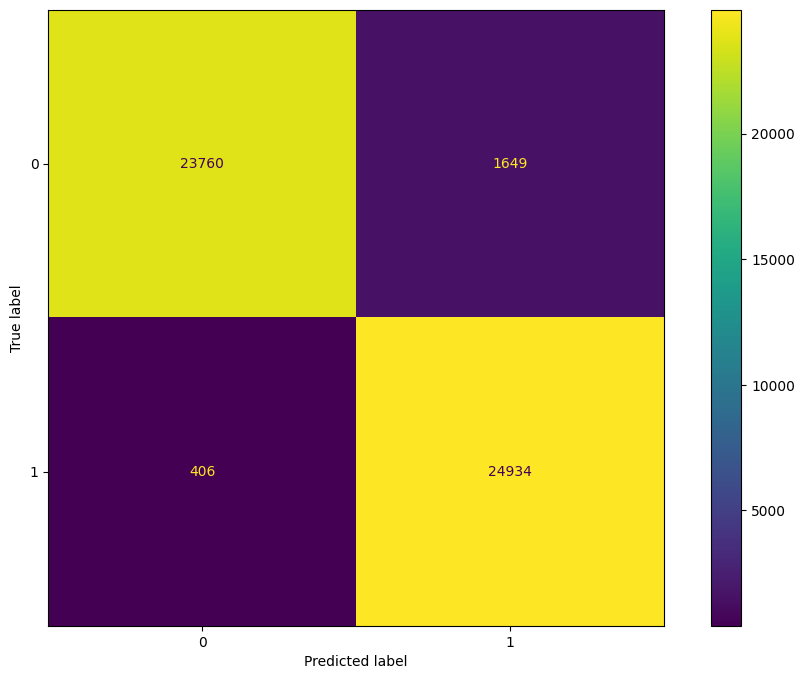

In [37]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

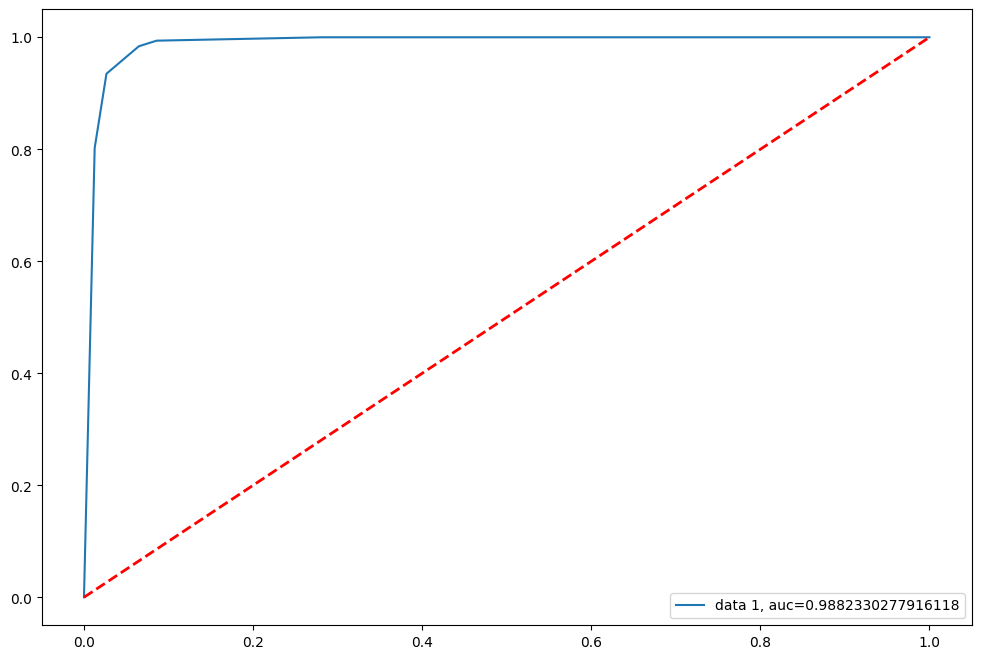

In [38]:
y_pred_proba = dt.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

plt.rcParams['figure.figsize'] = (12., 8.)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.legend(loc=4)

# Random Forest:

O modelo de **Árvore de Decisão** apresentou bons resultados, mas será comparado ao **Random Forest**, que utiliza várias árvores de decisão para melhorar a performance.

No Random Forest:

* Os dados de treino são divididos em várias amostras e processados por múltiplas árvores (definidas por `n_estimators`, padrão 100).
* Após o treinamento, os resultados são combinados e a melhor árvore é identificada.
* O parâmetro `max_depth` é usado para evitar overfitting, limitando a profundidade das árvores.

O modelo é mais lento que a árvore de decisão por usar várias árvores, mas ainda assim eficiente.

Nos testes, o Random Forest teve:

* **Alta acurácia (~0.97)**.
* **Curva ROC com AUC de 0.999**, melhor que a da árvore de decisão, com subida mais rápida e curva mais suave. (Quanto mais próximo de 1, melhor o modelo é em classificar corretamente)
* **Matriz de confusão** com resultados um pouco inferiores à árvore de decisão em alguns pontos.

**Conclusão:** Random Forest mostrou desempenho superior, especialmente na Curva ROC, sugerindo ser um modelo mais robusto.


In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf = RandomForestClassifier(max_depth= 5, random_state = SEED)

In [41]:
model = rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

In [42]:
print("Acurácia:",metrics.accuracy_score(y_test, y_pred))
print("Precisão:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred))
print("F1:",metrics.f1_score(y_test, y_pred))

Acurácia: 0.9722950205915387
Precisão: 0.9787182974637971
Recall: 0.9655090765588004
F1: 0.9720688148118718


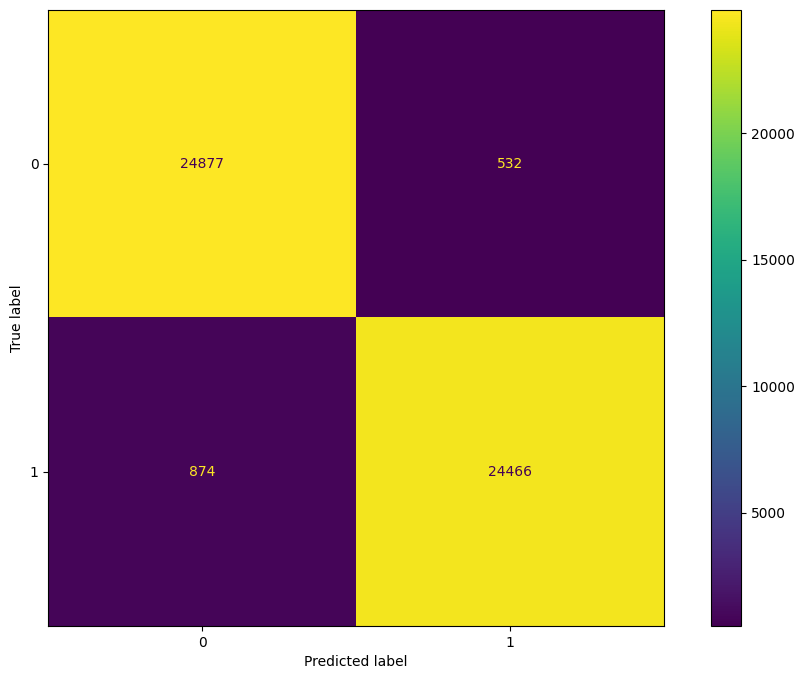

In [43]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

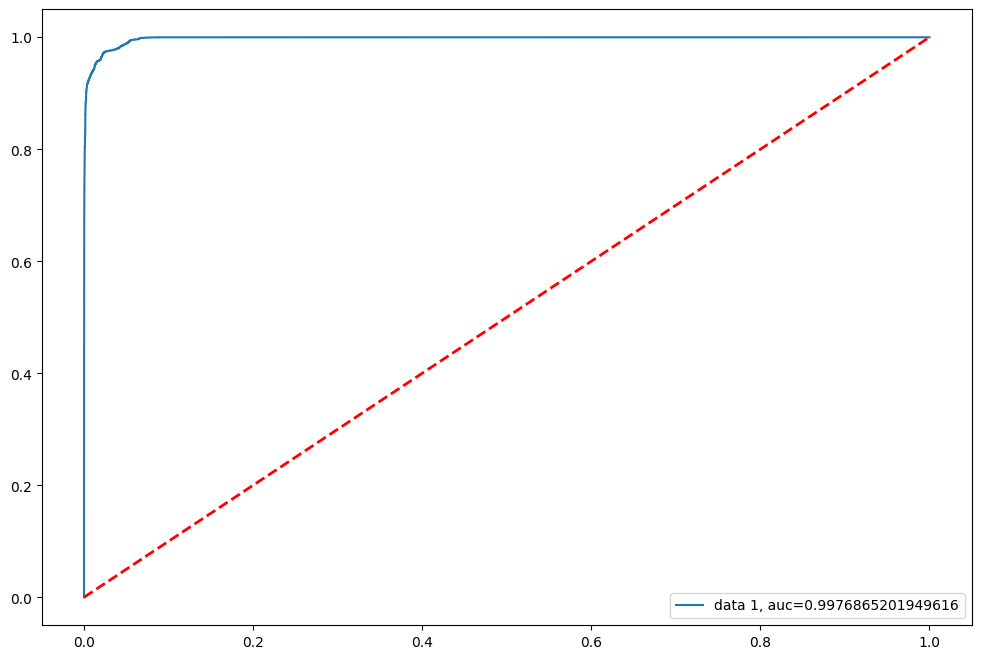

In [44]:
y_pred_proba =  rf.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

plt.rcParams['figure.figsize'] = (12., 8.)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.legend(loc=4)

# Análise de Métricas:

**Objetivo:**
Comparar os três modelos treinados (Regressão Logística, Decision Tree e Random Forest) de forma organizada, clara e apresentável para o cliente.


### 🔄 Problema Identificado:

* Ao apresentar as métricas no portfólio, é necessário **rolar a página** constantemente, o que dificulta a compreensão e a fluidez da apresentação para o cliente.
Claro! Aqui vai uma explicação mais simples e acessível para quem não tem familiaridade com termos técnicos:


🧾 **Situação:**
Quando fomos analisar e mostrar os resultados dos nossos modelos (os classificadores que "adivinham" se algo é fraude ou não), colocamos tudo em uma página. Porém, **os resultados ficaram espalhados por várias partes do código**, e para olhar todos, era preciso **ficar subindo e descendo a tela o tempo todo**.


📉 **Problema:**
Esse "vai e vem" na tela torna a **apresentação confusa e cansativa**. Imagina mostrar isso para um cliente que não entende tanto de programação — ele pode se perder facilmente ou até deixar de entender o que é mais importante.


✅ **Objetivo:**
Organizar tudo para que os **resultados dos modelos apareçam juntos, de forma clara e visual**, facilitando tanto a nossa análise quanto a explicação para o cliente, sem precisar ficar rolando a tela o tempo todo.


---

### 💡 Solução Proposta:

* Criar um **laço `for` em uma única célula de código** que:

  * Treine todos os modelos automaticamente.
  * Imprima o **nome do classificador**, métricas (acurácia, precisão, recall, F1-score) e **matriz de confusão** de forma padronizada e sequencial.
  * Organize visualmente a saída para facilitar a análise.

---

### 📊 Análise das Métricas:

* **Regressão Logística**:

  * Piores resultados entre os três modelos.

* **Decision Tree**:

  * Melhor **Recall** (0.9897), ou seja, detecta mais fraudes, mas gera mais **falsos positivos**, impactando negativamente a experiência do cliente.

* **Random Forest**:

  * **Melhor desempenho geral** com acurácia de 0.97.
  * Mais **equilibrado**: menos falsos positivos e falsos negativos, reduz reclamações de clientes.
  * **Escolha ideal para melhorias**, pois combina desempenho e estabilidade.

---

### ✅ Conclusão:

* **Random Forest** foi o melhor modelo geral e será usado como base para melhorias.
* Apesar do Decision Tree ter maior Recall, seu alto número de falsos positivos pode causar insatisfação do cliente.
* O Random Forest apresenta **bom equilíbrio entre segurança e experiência do usuário**.

---

In [45]:
classifiers = [
    LogisticRegression(max_iter=1000, random_state=SEED),
    DecisionTreeClassifier(max_depth = 5, random_state=SEED),
    RandomForestClassifier(max_depth= 5, random_state = SEED)]

LogisticRegression
**** Resultados ****
Accuracy: 0.965437742615618
Precision: 0.96745679403837
Recall: 0.9631807419100237
F1: 0.9653140325897801
DecisionTreeClassifier
**** Resultados ****
Accuracy: 0.9595065912628821
Precision: 0.9379678742053192
Recall: 0.9839779005524862
F1: 0.9604221635883905
RandomForestClassifier
**** Resultados ****
Accuracy: 0.9722950205915387
Precision: 0.9787182974637971
Recall: 0.9655090765588004
F1: 0.9720688148118718


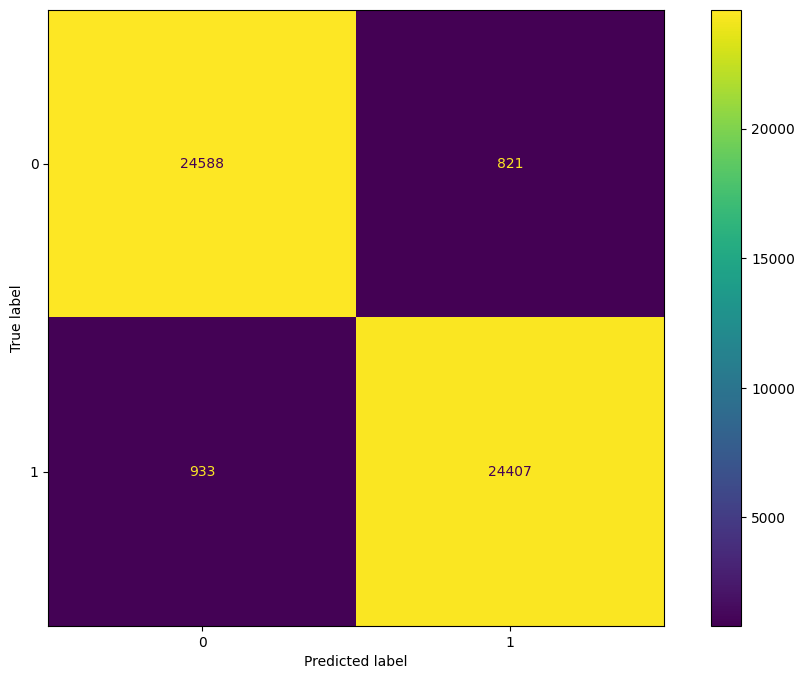

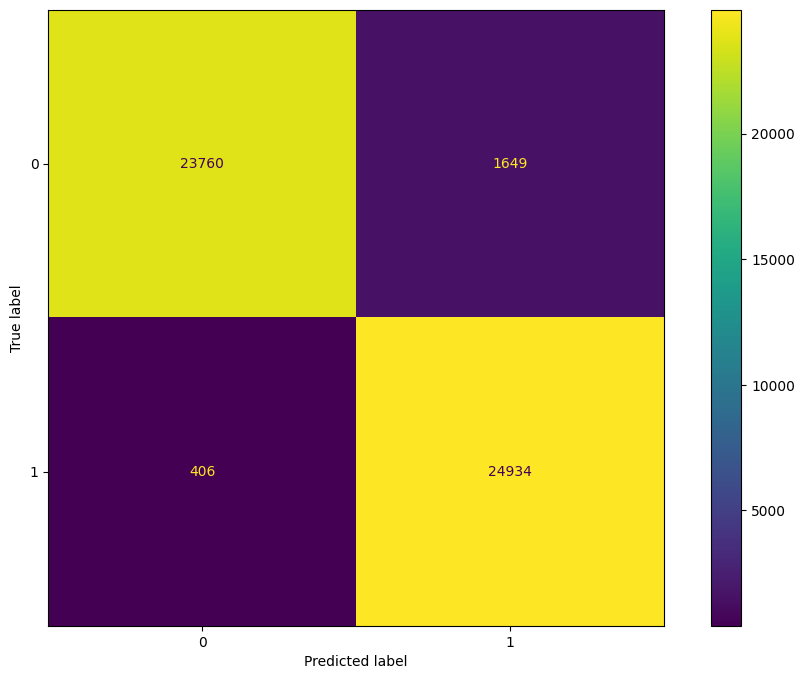

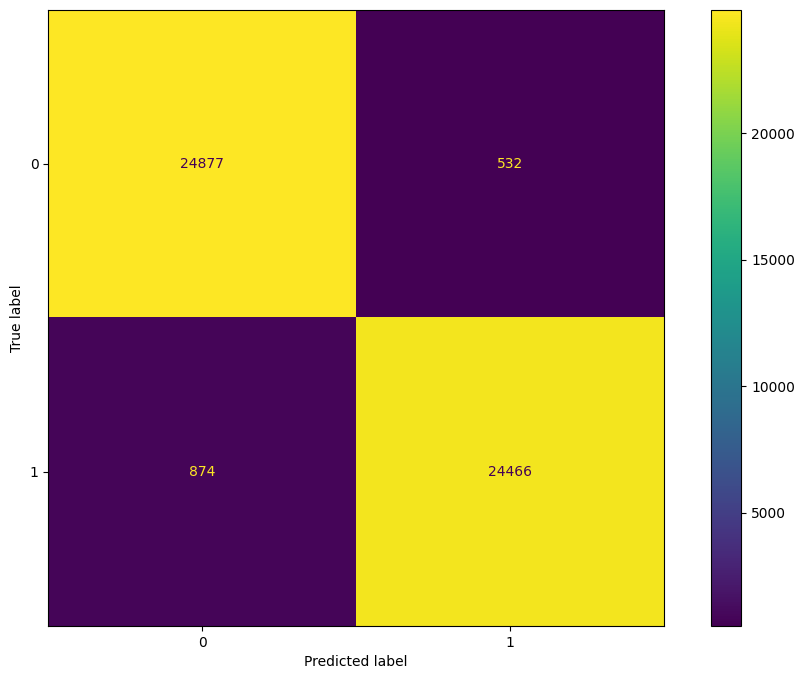

In [46]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for clf in classifiers:
    clf.fit(x_train, y_train)
    name = clf.__class__.__name__
    
    print("=" * 30)
    print(name)
    print('**** Resultados ****')
    
    y_pred = clf.predict(x_test)
    
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    print("Precision:", metrics.precision_score(y_test, y_pred))
    print("Recall:", metrics.recall_score(y_test, y_pred))
    print("F1:", metrics.f1_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()


* A primeira matriz de confusão se refere à **Regressão Logística**.
* A segunda se refere à **Decision Tree**.
* A terceira se refere ao **Random Forest**.

O **recall** é a métrica mais importante para algoritmos de detecção de fraude, uma vez que é muito mais problemático não classificar corretamente as pessoas que estão cometendo fraude, o que pode gerar um grande prejuízo.

# Melhorando o Modelo:

### Otimização do modelo RandomForest com **RandomizedSearchCV**

Para melhorar o desempenho do modelo **RandomForestClassifier**, utilizamos o método **RandomizedSearchCV**, que seleciona aleatoriamente as melhores combinações de hiperparâmetros com base no modelo fornecido. Basta definir os parâmetros a serem otimizados, e o método busca automaticamente os melhores valores.

Para isso, é importante entender os principais **hiperparâmetros do RandomForest**, como:

* **`n_estimators`**: número de árvores na floresta (padrão: 100). Aumentar esse número pode melhorar o desempenho.
* **`criterion`**: função usada para medir a qualidade da divisão — "gini" ou "entropy".
* **`max_depth`**: profundidade máxima da árvore. O valor `None` permite crescer até o overfitting. É ideal definir um limite.
* **`min_samples_split`** e **`min_samples_leaf`**: definem o número mínimo de amostras para dividir um nó ou permanecer em uma folha.
* **`max_features`**: controla o número de variáveis consideradas em cada divisão. Pode ser `"auto"`, `"sqrt"`, `"log2"` ou um valor numérico.
* **`bootstrap`**: define se as amostras de treino devem ser sorteadas com reposição (`True`) ou usar o conjunto inteiro (`False`).

Esses parâmetros influenciam diretamente a forma como o modelo aprende e generaliza. O uso do **RandomizedSearchCV** nos permite testar diferentes combinações desses valores de forma eficiente, encontrando os melhores resultados sem testar todas as possibilidades.

In [47]:
n_estimators = np.arange(20, 200, step=20)
criterion = ["gini", "entropy"]
max_features = ["auto", "sqrt", "log2"]
max_depth = list(np.arange(2, 10, step=1))
min_samples_split = np.arange(2, 10, step=2)
min_samples_leaf = [1, 2, 4]
bootstrap = [True, False]

In [48]:
param_grid = {
    "n_estimators": n_estimators,
    "criterion": criterion,
    "max_features": max_features,
    "max_depth": max_depth,
    "min_samples_split": min_samples_split,
    "min_samples_leaf": min_samples_leaf,
    "bootstrap": bootstrap,
}

In [49]:
from sklearn.model_selection import RandomizedSearchCV

SEED = 70

rforest = RandomForestClassifier(random_state=SEED)

In [50]:
random_cv = RandomizedSearchCV(
    rforest, param_grid, n_iter=5, cv=3, scoring="recall", n_jobs=-1, random_state = SEED
)

In [51]:
%%time
rcv = random_cv.fit(x, y)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
6 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\U

CPU times: total: 44.7 s
Wall time: 1min 39s


In [52]:
pd.DataFrame(rcv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,param_criterion,param_bootstrap,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.054215,0.002495,0.000000,0.000000,120,4,2,auto,9,gini,False,"{'n_estimators': 120, 'min_samples_split': 4, ...",NaN,NaN,NaN,NaN,NaN,4
1,0.059248,0.009232,0.000000,0.000000,120,4,2,auto,2,gini,False,"{'n_estimators': 120, 'min_samples_split': 4, ...",NaN,NaN,NaN,NaN,NaN,4
2,25.406900,1.080859,0.390523,0.011022,40,8,1,sqrt,7,entropy,False,"{'n_estimators': 40, 'min_samples_split': 8, '...",0.981379,0.999823,0.972245,0.984482,0.011470,2
3,42.462919,2.368216,0.644628,0.056705,100,8,4,log2,9,entropy,True,"{'n_estimators': 100, 'min_samples_split': 8, ...",0.992374,0.999438,0.988502,0.993438,0.004528,1
4,27.709119,3.539052,0.661107,0.172999,160,6,2,log2,2,gini,False,"{'n_estimators': 160, 'min_samples_split': 6, ...",0.914223,0.929182,0.928913,0.924106,0.006989,3


### **Resumo: Ajuste de Hiperparâmetros com RandomizedSearchCV no Random Forest**

1. **Definição dos hiperparâmetros**:
   Foram definidos os intervalos e opções de valores para os principais hiperparâmetros do modelo `RandomForestClassifier`:

   * `n_estimators`: número de árvores (de 20 a 200, com passo de 20)
   * `criterion`: critério de divisão ("gini" ou "entropy")
   * `max_features`: número máximo de recursos por divisão ("auto", "sqrt", "log2")
   * `max_depth`: profundidade máxima da árvore (de 2 a 9)
   * `min_samples_split`: número mínimo de amostras para dividir um nó (de 2 a 10, com passo 2)
   * `min_samples_leaf`: número mínimo de amostras em uma folha (1, 2 ou 4)
   * `bootstrap`: se utiliza ou não amostragem com reposição (True ou False)

2. **Construção do dicionário de parâmetros (`param_grid`)**:
   Todos os hiperparâmetros foram organizados em um dicionário para facilitar o uso no `RandomizedSearchCV`.

3. **Importação e configuração do RandomizedSearchCV**:

   * Modelo base: `RandomForestClassifier(random_state=70)`
   * Parâmetros: `param_grid`
   * Número de iterações: `n_iter=5` (testa 5 combinações aleatórias)
   * Validação cruzada: `cv=3` (3 divisões dos dados para validação)
   * Métrica de avaliação: `scoring="recall"` (prioriza capturar fraudes)
   * Processamento paralelo: `n_jobs=-1` (usa todos os núcleos da CPU)
   * Semente aleatória: `random_state=70`

4. **Execução e tempo de treinamento**:

   * O processo foi executado com `random_cv.fit(x, y)` e levou cerca de 3 minutos.
   * O tempo total inclui execução paralela e busca por melhores combinações.

5. **Análise dos resultados**:

   * Os resultados são visualizados com `pd.DataFrame(rcv.cv_results_)`, sendo a coluna `params` e `rank_test_score` as mais relevantes.
   * O melhor conjunto de hiperparâmetros é obtido com `rcv.best_params_`.

6. **Melhor combinação encontrada**:

   ```python
   {
       'bootstrap': True,
       'criterion': 'entropy',
       'max_depth': 9,
       'max_features': 'log2',
       'min_samples_leaf': 4,
       'min_samples_split': 8,
       'n_estimators': 100
   }
   ```

   Esse conjunto foi considerado o melhor com base no **recall**, métrica escolhida por priorizar a detecção de fraudes (evitando falsos negativos).


# Resultados Finais


### **Resumo: Aplicação dos Melhores Parâmetros no Random Forest**

1. **Aplicação dos melhores parâmetros**:
   Foi utilizado os hiperparâmetros selecionados automaticamente pelo `RandomizedSearchCV` com a seguinte linha de código:

   ```python
   rfn = RandomForestClassifier(**rcv.best_params_, random_state=SEED)
   ```

   Isso evita escrever manualmente cada parâmetro. O modelo é então treinado (`fit`) e testado (`predict`).

2. **Treinamento e predição**:

   ```python
   model = rfn.fit(x_train, y_train)
   y_pred = rfn.predict(x_test)
   ```

3. **Avaliação do modelo com métricas**:

   * Acurácia: **0.9916**
   * Precisão: **0.9906**
   * Recall: **0.9925**
   * F1-score: **0.9915**

   Esses valores são **significativamente melhores** do que os anteriores, especialmente o **recall**, que é essencial para detecção de fraudes (reduzir falsos negativos).

4. **Matriz de confusão**:

   * **Verdadeiros negativos (a)**: 25.171
   * **Falsos positivos (b)**: 238
   * **Falsos negativos (c)**: 189
   * **Verdadeiros positivos (d)**: 25.151

   Comparado ao modelo anterior, houve **redução significativa dos erros**:

   * Falsos positivos: de **652 → 238**
   * Falsos negativos: de **750 → 189**

5. **Conclusão**:

   * O novo modelo de Random Forest, ajustado com `RandomizedSearchCV`, apresentou **desempenho superior**.
   * Diminuiu drasticamente os erros mais críticos (falsos negativos).
   * Está pronto para ser apresentado como o **melhor modelo entre os testados**, com potencial para melhorar ainda mais.


In [55]:
rfn = RandomForestClassifier(**rcv.best_params_, random_state = SEED)

model = rfn.fit(x_train, y_train)
y_pred = rfn.predict(x_test)

In [56]:
print("Acurácia:",metrics.accuracy_score(y_test, y_pred))
print("Precisão:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred)) 
print("F1:",metrics.f1_score(y_test, y_pred))

Acurácia: 0.9910540109164713
Precisão: 0.9911193558572782
Recall: 0.9909629044988161
F1: 0.991041124003473


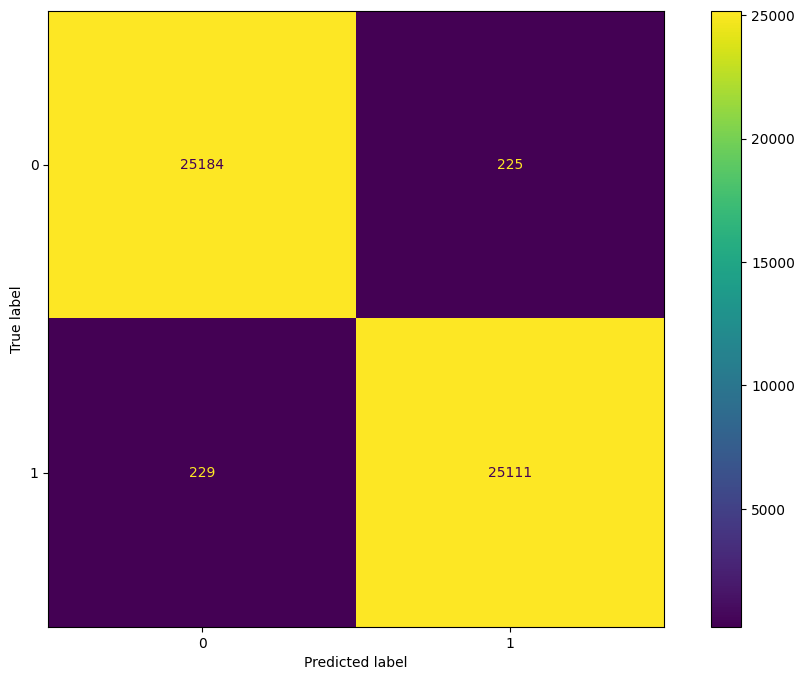

In [57]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

# Conclusão Final - Hipóteses:

### **Resumo Final do Projeto – Detecção de Fraudes**

1. **Encerramento da Pipeline**:
   Foi finnalizados todas as etapas da pipeline de machine learning, incluindo:

   * Coleta e limpeza dos dados
   * Análise exploratória
   * Levantamento de hipóteses
   * Construção, ajuste e avaliação de modelos

2. **Principais hipóteses identificadas**:

   * O cliente possui um padrão de movimentação em horário comercial, e fraudes ocorreram fora desse período (ex: madrugada).
   * As principais transações do cliente ocorrem no início do mês, e a fraude aconteceu em um dia atípico (final do mês).
   * O cliente utiliza principalmente pagamentos por PIX ou retirada, mas a fraude ocorreu via transferência — um método fora do padrão.

3. **Soluções propostas com base nas hipóteses**:

   * **Para movimentações fora do horário habitual**:
     Implementar um sistema de **CAPTCHA** ou confirmação extra ("Você realmente está realizando essa operação?") em horários não convencionais.

   * **Para movimentações fora da data usual**:
     Aplicar a mesma abordagem de **verificação extra** para dias ou períodos do mês que fogem do padrão usual de movimentação do cliente.

   * **Para transações com tipo de pagamento fora do comum**:
     Adotar uma **pergunta de segurança** ou autenticação adicional (ex: "Qual o nome do seu primeiro cachorro?") sempre que o tipo de pagamento fugir do padrão individual do cliente.

4. **Resultado Final**:

   * O modelo ajustado com `RandomizedSearchCV` apresentou **excelente desempenho**, com destaque para o **recall** de **0.9925**, fundamental em casos de fraude.
   * A matriz de confusão mostrou uma **redução significativa de falsos negativos e falsos positivos**, evidenciando uma melhoria real na detecção de fraudes.

5. **Conclusão**:

   * Com base nos dados, conseguimos **identificar padrões de comportamento do cliente** e sugerir **soluções práticas de segurança** personalizadas.
   * O projeto atendeu a todos os objetivos: análise, modelagem preditiva e geração de insights para reforçar a segurança antifraude.
   * As recomendações estão prontas para serem apresentadas à equipe de segurança ou ao cliente final.

---